In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from pathlib import Path

In [2]:
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)

[PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon/base_1000_20p'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon/base_10000_20p'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon/1000_10p'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon/10000_10p'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon/some_fixed_high_ksoil'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon/some_fixed_low_ksoil'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon/.DS_Store')]

In [3]:
scenario_name = "some_fixed_low_ksoil"
input_path = os.path.join(root_output_directory, scenario_name,'input')
output_path = os.path.join(root_output_directory, scenario_name,'output')
post_path = os.path.join(root_output_directory, scenario_name,'post')
vars_all = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
        'leaf_hydraulic_capacitance', 'psi50_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0', 'jackson_root_beta',
        'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation', 'g_bark']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0', 'jackson_root_beta']

In [4]:
df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
df_grp = df.groupby(['id'])[vars_all].mean()
dv = df_grp
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
df_norm = (dv - dv.mean()) / dv.std()
#df_norm = (dv - dv.min()) / dv.std()
#df_norm['sid'] = df['sid']

In [5]:
df_norm

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark
id,,,,,,,,,,,,,,,,,
0,-0.050901,-1.582038,-0.371380,-1.370371,0.172780,-0.864422,-0.681718,-0.250598,1.506968,0.022253,1.287384,0.532804,1.024278,0.650995,-1.381039,0.562037,-0.118845
1,0.351696,-0.030117,-0.087754,0.517461,-0.945320,-0.657859,-1.146532,-0.761658,-0.685781,-1.033240,1.433909,-0.676763,-0.264855,0.041617,0.937236,-0.087729,-0.866463
2,0.594070,0.626251,-0.417586,0.424147,-0.412140,-0.893485,-0.637614,-1.184365,0.663247,-0.826242,0.209703,-0.622293,-1.569341,0.025122,-1.913389,0.586213,-1.235640
3,0.116187,0.065056,-1.309142,0.632421,0.712264,1.241947,-0.841413,-0.127811,-0.566879,-0.503911,1.021505,1.048932,0.731256,0.182886,0.708679,0.513854,-0.078245
4,-0.153141,0.802993,0.229953,0.396434,0.461705,0.807364,-1.199198,2.358224,-0.933907,1.480780,-0.354287,-0.271926,0.809020,-0.424799,-0.572334,0.427649,1.744920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1935,-0.346674,-1.245784,-0.516260,1.056369,-0.154544,-1.250463,1.165503,-0.287557,1.031243,-0.283021,0.951655,-0.501222,0.127901,-0.266092,-0.488131,1.056685,-0.168366
1936,-0.388836,1.593950,-0.538835,0.318070,0.066669,-0.852332,0.842629,0.309093,1.064221,1.047340,0.443281,-1.384057,0.309396,0.397747,-1.777685,0.404669,-0.162102
1937,-1.613289,0.445456,0.464749,-0.797287,0.297159,-1.404067,-1.575911,1.740489,-0.355765,-0.160493,-0.147347,-1.242873,0.949501,-1.456906,1.216652,0.786787,1.265489


In [7]:
from sklearn.cluster import OPTICS
import seaborn as sns
from sklearn.metrics import silhouette_score

In [12]:
model = OPTICS(min_cluster_size=10)
model.fit(df_norm)
silhouette_score(df_norm, model.labels_, metric='euclidean')

ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

<Axes: >

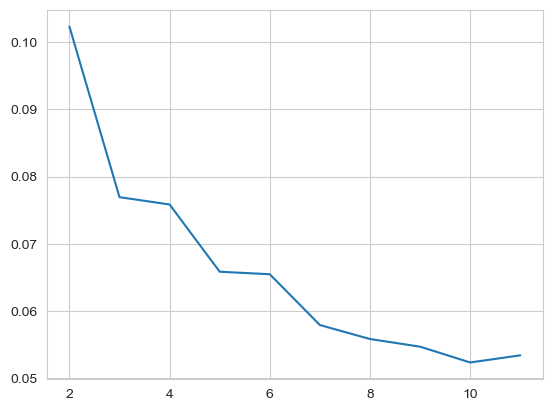

In [7]:
K = range(2, 12)
fits = []
score = []

for k in K:
    # train the model for current value of k on training data
    model = KMeans(n_clusters = k, random_state = 0, n_init='auto').fit(df_norm)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    score.append(silhouette_score(df_norm, model.labels_, metric='euclidean'))
sns.lineplot(x = K, y = score)


In [35]:
df_norm.values

array([[-0.0509014 , -1.58203806, -0.3713801 , ..., -1.38103941,
         0.5620367 , -0.11884477],
       [ 0.35169648, -0.03011719, -0.08775422, ...,  0.93723581,
        -0.0877295 , -0.86646301],
       [ 0.59406992,  0.62625093, -0.41758598, ..., -1.91338874,
         0.58621306, -1.23563981],
       ...,
       [-1.61328895,  0.44545583,  0.46474888, ...,  1.21665205,
         0.78678682,  1.26548946],
       [ 1.37773106, -0.72538324,  1.44815435, ...,  0.64885181,
         0.47131741,  2.2992083 ],
       [ 0.97312215,  1.33345402,  1.14495997, ...,  0.44121102,
         0.68381239,  0.6907126 ]])

In [ ]:
from pyclustering.cluster.clique import clique, clique_visualizer
from pyclustering.utils import read_sample
from pyclustering.samples.definitions import FCPS_SAMPLES
# read two-dimensional input data 'Target'
data = read_sample(FCPS_SAMPLES.SAMPLE_TARGET)
# create CLIQUE algorithm for processing
intervals = 10  # defines amount of cells in grid in each dimension
threshold = 0   # lets consider each point as non-outlier
clique_instance = clique(df_norm.values, intervals, threshold)
# start clustering process and obtain results
clique_instance.process()
clusters = clique_instance.get_clusters()  # allocated clusters
noise = clique_instance.get_noise()     # points that are considered as outliers (in this example should be empty)
cells = clique_instance.get_cells()     # CLIQUE blocks that forms grid
print("Amount of clusters:", len(clusters))
# visualize clustering results
clique_visualizer.show_grid(cells, data)    # show grid that has been formed by the 

In [10]:
data

[[-3.0, -3.0],
 [-3.0, 3.0],
 [3.0, -3.0],
 [3.0, 3.0],
 [-0.417091, 0.114782],
 [0.054031, 0.296411],
 [-0.337597, 0.346704],
 [-0.0469, -0.319833],
 [0.000955, -0.07788],
 [0.163704, -0.171811],
 [-0.140118, 0.163781],
 [0.228946, -0.032098],
 [0.379642, -0.006396],
 [-0.38736, -0.217393],
 [-0.077707, -0.28845],
 [-0.141468, -0.132688],
 [0.132764, -0.312654],
 [-0.157673, -0.279198],
 [-0.25882, -0.08331],
 [0.032572, -0.274695],
 [-0.333664, 0.15261],
 [-0.48088, 0.023882],
 [-0.06806, -0.368618],
 [0.36105, -0.001467],
 [0.276191, -0.309596],
 [-0.198664, 0.024887],
 [-0.256391, -0.000411],
 [-0.028428, -0.240332],
 [-0.055645, 0.395318],
 [0.074451, -0.493023],
 [-0.026067, 0.361214],
 [0.383108, -0.118063],
 [-0.021727, 0.357367],
 [0.102986, -0.30644],
 [0.468553, 0.087124],
 [0.12418, -0.466284],
 [-0.257262, -0.344154],
 [0.164727, -0.305763],
 [0.1532, -0.166946],
 [-0.196484, 0.361061],
 [-0.164265, -0.423242],
 [-0.115913, 0.141906],
 [0.234838, -0.284737],
 [0.435577, -0